## Series de Tiempo y Modelos Econométricos

In [3]:
# cargamos los datos
import pandas as pd
data = pd.read_csv('Mercado laboral y población.csv', sep=';')
# mostramos las primeras filas del dataframe
data.head()

,"Periodo(MMM, AAAA)",Tasa de desempleo - total nacional,Tasa de ocupación - total nacional
0,2001/01/31,"16,62","57,58"
1,2001/02/28,"17,43","56,93"
2,2001/03/31,"15,81","57,57"
3,2001/04/30,"14,52","55,76"
4,2001/05/31,"14,04","56,23"


In [4]:
# importamos libreria de series de tiempo
import statsmodels.api as sm


In [8]:
# las variables son
data.dtypes

Periodo(MMM, AAAA)                    str
Tasa de desempleo - total nacional    str
Tasa de ocupación - total nacional    str
dtype: object

In [9]:
# ver en blanco
data.isnull().sum()

Periodo(MMM, AAAA)                    0
Tasa de desempleo - total nacional    0
Tasa de ocupación - total nacional    0
dtype: int64

In [10]:
# tengo que cambiar el formato de las tasas de desempleo a formato numérico
data['Tasa de desempleo - total nacional'] = data['Tasa de desempleo - total nacional'].str.replace(',', '.').astype(float)
data['Tasa de ocupación - total nacional'] = data['Tasa de ocupación - total nacional'].str.replace(',', '.').astype(float)

In [11]:
# comprobamos 
data.dtypes

Periodo(MMM, AAAA)                        str
Tasa de desempleo - total nacional    float64
Tasa de ocupación - total nacional    float64
dtype: object

In [16]:
# la columna de periodo debe ser de tipo fecha
data['Periodo(MMM, AAAA)'] = pd.to_datetime(
    data['Periodo(MMM, AAAA)'],
    format='mixed',
    errors='coerce'
)
# comprobamos
data.dtypes


Periodo(MMM, AAAA)                    datetime64[us]
Tasa de desempleo - total nacional           float64
Tasa de ocupación - total nacional           float64
dtype: object

In [17]:
#rango de fechas
data['Periodo(MMM, AAAA)'].min(), data['Periodo(MMM, AAAA)'].max()

(Timestamp('2001-01-31 00:00:00'), Timestamp('2026-01-31 00:00:00'))

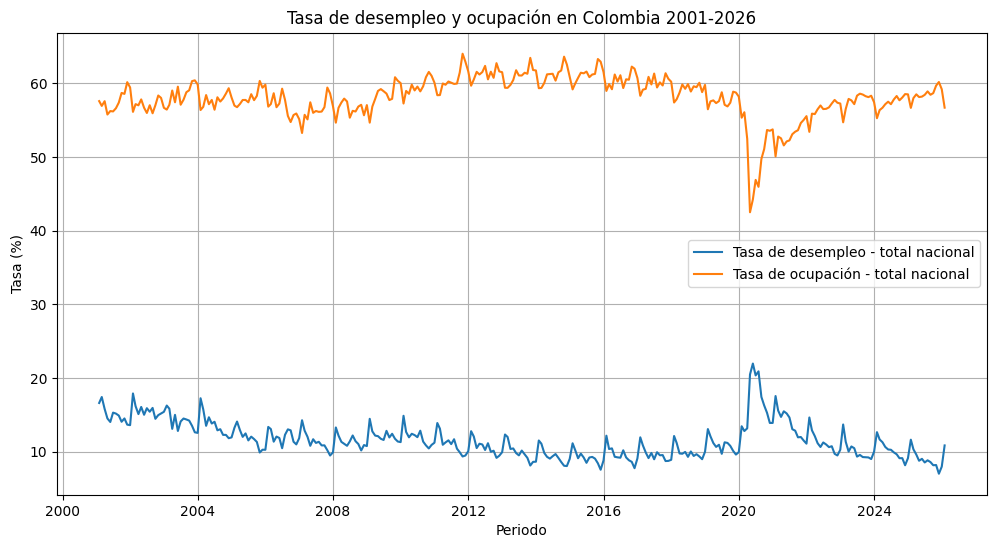

In [22]:
# ahora visualicemos las series de tiempo
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(data['Periodo(MMM, AAAA)'], data['Tasa de desempleo - total nacional'], label='Tasa de desempleo - total nacional')
plt.plot(data['Periodo(MMM, AAAA)'], data['Tasa de ocupación - total nacional'], label='Tasa de ocupación - total nacional')
plt.xlabel('Periodo')
plt.ylabel('Tasa (%)')  
plt.title('Tasa de desempleo y ocupación en Colombia 2001-2026')
plt.legend()
plt.grid()
plt.show()